In [1]:
"""
NBA Movement Data - Exploratory Data Analysis
Usage: python explore_data.py <path_to_data_dir>
Example: python explore_data.py ./sample_data/nba_movement_data
"""
import sys
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
DATA_DIR = "data"
# --- flat CSVs ---
games        = pd.read_csv(os.path.join(DATA_DIR, "games.csv"))
players      = pd.read_csv(os.path.join(DATA_DIR, "players.csv"))
teams        = pd.read_csv(os.path.join(DATA_DIR, "teams.csv"))
minutes      = pd.read_csv(os.path.join(DATA_DIR, "minutes_played.csv"))

event_files  = glob.glob(os.path.join(DATA_DIR, "events", "*.csv"))
events       = pd.concat([pd.read_csv(f) for f in event_files], ignore_index=True)

moment_files = glob.glob(os.path.join(DATA_DIR, "moments", "*.csv"))
moments      = pd.concat([pd.read_csv(f) for f in moment_files], ignore_index=True)

In [3]:
games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-03-12,22101005,Final,1610612748,1610612750,2021,1610612748,104.0,0.398,0.760,...,23.0,53.0,1610612750,113.0,0.422,0.875,0.357,21.0,46.0,0
1,2022-03-12,22101006,Final,1610612741,1610612739,2021,1610612741,101.0,0.443,0.933,...,20.0,46.0,1610612739,91.0,0.419,0.824,0.208,19.0,40.0,1
2,2022-03-12,22101007,Final,1610612759,1610612754,2021,1610612759,108.0,0.412,0.813,...,28.0,52.0,1610612754,119.0,0.489,1.000,0.389,23.0,47.0,0
3,2022-03-12,22101008,Final,1610612744,1610612749,2021,1610612744,122.0,0.484,0.933,...,33.0,55.0,1610612749,109.0,0.413,0.696,0.386,27.0,39.0,1
4,2022-03-12,22101009,Final,1610612743,1610612761,2021,1610612743,115.0,0.551,0.750,...,32.0,39.0,1610612761,127.0,0.471,0.760,0.387,28.0,50.0,0


In [4]:
players.head()

,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
0,Royce O'Neale,1610612762,1626220,2019
1,Bojan Bogdanovic,1610612762,202711,2019
2,Rudy Gobert,1610612762,203497,2019
3,Donovan Mitchell,1610612762,1628378,2019
4,Mike Conley,1610612762,201144,2019


In [5]:
teams.head()

,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends


In [6]:
minutes.head()

,GAME_ID,PLAYER_ID,SEC
0,21500659,203503,1552.0
1,21500659,201959,1727.0
2,21500659,2200,1983.0
3,21500659,202710,2548.0
4,21500659,201565,2116.0


In [7]:
events.head()

,GAME_ID,EVENTNUM,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,PLAYER2_TEAM_CITY,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION
0,21500548,0,12,0,1,10:12 PM,12:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
1,21500548,1,10,0,1,10:13 PM,12:00,Jump Ball Plumlee vs. Bogut: Tip to Green,NaN,NaN,...,Golden State,Warriors,GSW,5,203110,Draymond Green,1.610613e+09,Golden State,Warriors,GSW
2,21500548,2,2,86,1,10:13 PM,11:49,NaN,NaN,MISS Thompson 15' Turnaround Fadeaway Shot,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
3,21500548,3,4,0,1,10:13 PM,11:48,Plumlee REBOUND (Off:0 Def:1),NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
4,21500548,4,2,1,1,10:13 PM,11:39,MISS Lillard 22' Jump Shot,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN


In [8]:
moments.head()

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1
3,1610612757,203486,76.35817,32.72804,0.00000,714.28,17.37,1,21500548,1
4,1610612757,203468,83.68322,6.07262,0.00000,714.28,17.37,1,21500548,1


In [9]:
moments.describe()

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
count,2.303443e+06,2.303443e+06,2.303443e+06,2.303443e+06,2.303443e+06,2.303443e+06,2.121192e+06,2.303443e+06,2303443.0,2.303443e+06
mean,1.464481e+09,1.788498e+05,4.547496e+01,2.498580e+01,4.361646e-01,3.539077e+02,1.765186e+01,2.496189e+00,21500548.0,2.734044e+02
std,4.626096e+08,1.552076e+05,2.872752e+01,1.158206e+01,1.677022e+00,2.062853e+02,4.978872e+00,1.097223e+00,0.0,1.601047e+02
min,-1.000000e+00,-1.000000e+00,-7.436340e+00,-3.086930e+00,0.000000e+00,0.000000e+00,1.000000e-02,1.000000e+00,21500548.0,1.000000e+00
25%,1.610613e+09,2.015750e+05,1.853698e+01,1.644915e+01,0.000000e+00,1.877300e+02,1.431000e+01,2.000000e+00,21500548.0,1.300000e+02
50%,1.610613e+09,2.030810e+05,4.183407e+01,2.502888e+01,0.000000e+00,3.463100e+02,1.779000e+01,2.000000e+00,21500548.0,2.900000e+02
75%,1.610613e+09,2.031100e+05,7.351433e+01,3.350894e+01,0.000000e+00,5.301900e+02,2.222000e+01,3.000000e+00,21500548.0,4.120000e+02
max,1.610613e+09,1.626192e+06,9.984167e+01,5.310785e+01,1.730120e+01,7.184300e+02,2.400000e+01,4.000000e+00,21500548.0,5.390000e+02


In [10]:
# ─────────────────────────────────────────────────────────────
# HELPER
# ─────────────────────────────────────────────────────────────
def basic_info(df, name):
    print(f"{'='*55}")
    print(f"  {name}  —  {df.shape[0]:,} rows  x  {df.shape[1]} cols")
    print(f"{'='*55}")

    summary = pd.DataFrame({
        "dtype"    : df.dtypes,
        "non_null" : df.notnull().sum(),
        "null"     : df.isnull().sum(),
        "null_%"   : (df.isnull().mean() * 100).round(1),
        "nunique"  : df.nunique(),
        "sample"   : [df[c].dropna().iloc[0] if df[c].notnull().any() else None for c in df.columns],
    })
    display(summary)

In [11]:
basic_info(games, "games")

print("\n  First 3 rows:")
display(games.head(3))

print(f"\n  Duplicate game_id rows: {games.duplicated('GAME_ID').sum()}")
print(f"  Unique game_ids: {games['GAME_ID'].nunique()}")


  games  —  25,796 rows  x  21 cols


,dtype,non_null,null,null_%,nunique,sample
GAME_DATE_EST,str,25796,0,0.0,4149,2022-03-12
GAME_ID,int64,25796,0,0.0,25767,22101005
GAME_STATUS_TEXT,str,25796,0,0.0,1,Final
HOME_TEAM_ID,int64,25796,0,0.0,30,1610612748
VISITOR_TEAM_ID,int64,25796,0,0.0,30,1610612750
SEASON,int64,25796,0,0.0,19,2021
TEAM_ID_home,int64,25796,0,0.0,30,1610612748
PTS_home,float64,25697,99,0.4,100,104.0
FG_PCT_home,float64,25697,99,0.4,399,0.398
FT_PCT_home,float64,25697,99,0.4,403,0.76



  First 3 rows:


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-03-12,22101005,Final,1610612748,1610612750,2021,1610612748,104.0,0.398,0.760,...,23.0,53.0,1610612750,113.0,0.422,0.875,0.357,21.0,46.0,0
1,2022-03-12,22101006,Final,1610612741,1610612739,2021,1610612741,101.0,0.443,0.933,...,20.0,46.0,1610612739,91.0,0.419,0.824,0.208,19.0,40.0,1
2,2022-03-12,22101007,Final,1610612759,1610612754,2021,1610612759,108.0,0.412,0.813,...,28.0,52.0,1610612754,119.0,0.489,1.000,0.389,23.0,47.0,0



  Duplicate game_id rows: 29
  Unique game_ids: 25767


In [12]:
basic_info(players, "players")

print("\n  First 3 rows:")
display(players.head(3))

print(f"\n  Duplicate player_id rows: {players.duplicated('PLAYER_ID').sum()}")


  players  —  7,228 rows  x  4 cols


,dtype,non_null,null,null_%,nunique,sample
PLAYER_NAME,str,7228,0,0.0,1749,Royce O'Neale
TEAM_ID,int64,7228,0,0.0,30,1610612762
PLAYER_ID,int64,7228,0,0.0,1769,1626220
SEASON,int64,7228,0,0.0,11,2019



  First 3 rows:


,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
0,Royce O'Neale,1610612762,1626220,2019
1,Bojan Bogdanovic,1610612762,202711,2019
2,Rudy Gobert,1610612762,203497,2019



  Duplicate player_id rows: 5459


In [13]:
basic_info(teams, "teams")
display(teams)  # small enough to show all


  teams  —  30 rows  x  14 cols


,dtype,non_null,null,null_%,nunique,sample
LEAGUE_ID,int64,30,0,0.0,1,0
TEAM_ID,int64,30,0,0.0,30,1610612737
MIN_YEAR,int64,30,0,0.0,15,1949
MAX_YEAR,int64,30,0,0.0,1,2019
ABBREVIATION,str,30,0,0.0,30,ATL
NICKNAME,str,30,0,0.0,30,Hawks
YEARFOUNDED,int64,30,0,0.0,15,1949
CITY,str,30,0,0.0,29,Atlanta
ARENA,str,30,0,0.0,29,State Farm Arena
ARENACAPACITY,float64,26,4,13.3,24,18729.0


,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends
5,0,1610612743,1976,2019,DEN,Nuggets,1976,Denver,Pepsi Center,19099.0,Stan Kroenke,Tim Connelly,Michael Malone,No Affiliate
6,0,1610612745,1967,2019,HOU,Rockets,1967,Houston,Toyota Center,18104.0,Tilman Fertitta,Daryl Morey,Mike D'Antoni,Rio Grande Valley Vipers
7,0,1610612746,1970,2019,LAC,Clippers,1970,Los Angeles,Staples Center,19060.0,Steve Ballmer,Michael Winger,Doc Rivers,Agua Caliente Clippers of Ontario
8,0,1610612747,1948,2019,LAL,Lakers,1948,Los Angeles,Staples Center,19060.0,Jerry Buss Family Trust,Rob Pelinka,Frank Vogel,South Bay Lakers
9,0,1610612748,1988,2019,MIA,Heat,1988,Miami,AmericanAirlines Arena,19600.0,Micky Arison,Pat Riley,Erik Spoelstra,Sioux Falls Skyforce


In [14]:
basic_info(minutes, "minutes_played")

print("\n  First 3 rows:")
display(minutes.head(3))

  minutes_played  —  2,159 rows  x  3 cols


,dtype,non_null,null,null_%,nunique,sample
GAME_ID,int64,2159,0,0.0,84,21500659.0
PLAYER_ID,int64,2159,0,0.0,426,203503.0
SEC,float64,1839,320,14.8,1299,1552.0



  First 3 rows:


,GAME_ID,PLAYER_ID,SEC
0,21500659,203503,1552.0
1,21500659,201959,1727.0
2,21500659,2200,1983.0


In [15]:
events_sorted = events.sort_values("EVENTMSGTYPE")
events_sorted

,GAME_ID,EVENTNUM,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,PLAYER2_TEAM_CITY,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION
467,21500548,537,1,79,4,12:16 AM,0:15,Crabbe 15' Pullup Jump Shot (18 PTS),NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
18,21500548,20,1,85,1,10:16 PM,9:49,NaN,NaN,Curry 14' Turnaround Bank Shot (5 PTS),...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
21,21500548,23,1,41,1,10:16 PM,9:29,NaN,NaN,Green 3' Running Layup (2 PTS),...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
28,21500548,31,1,98,1,10:17 PM,8:32,NaN,NaN,Thompson 3' Cutting Layup Shot (2 PTS) (Curry ...,...,Golden State,Warriors,GSW,0,0,NaN,NaN,NaN,NaN,NaN
445,21500548,514,1,1,4,12:12 AM,2:45,NaN,NaN,Rush 3PT Jump Shot (20 PTS) (Thompson 5 AST),...,Golden State,Warriors,GSW,0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,21500548,300,13,0,2,11:12 PM,0:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
468,21500548,539,13,0,4,12:16 AM,0:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
105,21500548,119,13,0,1,10:36 PM,0:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
357,21500548,417,13,0,3,11:49 PM,0:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN


In [16]:
basic_info(events, "events")

print("\n  First 3 rows:")
display(events.head(3))

print("\n  EVENTMSGTYPE distribution:")
display(events["EVENTMSGTYPE"].value_counts().rename_axis("type").reset_index(name="count"))


  events  —  469 rows  x  33 cols


,dtype,non_null,null,null_%,nunique,sample
GAME_ID,int64,469,0,0.0,1,21500548
EVENTNUM,int64,469,0,0.0,469,0
EVENTMSGTYPE,int64,469,0,0.0,13,12
EVENTMSGACTIONTYPE,int64,469,0,0.0,40,0
PERIOD,int64,469,0,0.0,4,1
WCTIMESTRING,str,469,0,0.0,92,10:12 PM
PCTIMESTRING,str,469,0,0.0,261,12:00
HOMEDESCRIPTION,str,251,218,46.5,236,Jump Ball Plumlee vs. Bogut: Tip to Green
NEUTRALDESCRIPTION,float64,0,469,100.0,0,None
VISITORDESCRIPTION,str,234,235,50.1,219,MISS Thompson 15' Turnaround Fadeaway Shot



  First 3 rows:


,GAME_ID,EVENTNUM,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,PLAYER2_TEAM_CITY,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION
0,21500548,0,12,0,1,10:12 PM,12:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
1,21500548,1,10,0,1,10:13 PM,12:00,Jump Ball Plumlee vs. Bogut: Tip to Green,NaN,NaN,...,Golden State,Warriors,GSW,5,203110,Draymond Green,1.610613e+09,Golden State,Warriors,GSW
2,21500548,2,2,86,1,10:13 PM,11:49,NaN,NaN,MISS Thompson 15' Turnaround Fadeaway Shot,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN



  EVENTMSGTYPE distribution:


,type,count
0,4,110
1,2,99
2,1,84
3,3,49
4,8,42
5,6,37
6,5,24
7,9,11
8,12,4
9,13,4


In [17]:
moments

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1
3,1610612757,203486,76.35817,32.72804,0.00000,714.28,17.37,1,21500548,1
4,1610612757,203468,83.68322,6.07262,0.00000,714.28,17.37,1,21500548,1
...,...,...,...,...,...,...,...,...,...,...
2303438,1610612744,201575,43.66537,40.42003,0.00000,0.04,NaN,4,21500548,539
2303439,1610612744,201578,44.70719,15.92969,0.00000,0.04,NaN,4,21500548,539
2303440,1610612744,203105,73.66245,0.95057,0.00000,0.04,NaN,4,21500548,539
2303441,1610612744,203546,43.85332,29.92151,0.00000,0.04,NaN,4,21500548,539


In [18]:
moments_copy = moments.copy()
moments_copy["x_loc"] = moments_copy["x_loc"] * 0.3048
moments_copy["y_loc"] = moments_copy["y_loc"] * 0.3048
moments_copy["radius"] = moments_copy["radius"] * 0.3048
moments_copy

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,14.394680,9.404647,1.261835,714.28,17.37,1,21500548,1
1,1610612757,202329,25.755630,10.921429,0.000000,714.28,17.37,1,21500548,1
2,1610612757,203081,18.630111,8.708743,0.000000,714.28,17.37,1,21500548,1
3,1610612757,203486,23.273970,9.975507,0.000000,714.28,17.37,1,21500548,1
4,1610612757,203468,25.506645,1.850935,0.000000,714.28,17.37,1,21500548,1
...,...,...,...,...,...,...,...,...,...,...
2303438,1610612744,201575,13.309205,12.320025,0.000000,0.04,NaN,4,21500548,539
2303439,1610612744,201578,13.626752,4.855370,0.000000,0.04,NaN,4,21500548,539
2303440,1610612744,203105,22.452315,0.289734,0.000000,0.04,NaN,4,21500548,539
2303441,1610612744,203546,13.366492,9.120076,0.000000,0.04,NaN,4,21500548,539


  moments  —  2,303,443 rows  x  10 cols


,dtype,non_null,null,null_%,nunique,sample
team_id,int64,2303443,0,0.0,3,-1.000000e+00
player_id,int64,2303443,0,0.0,24,-1.000000e+00
x_loc,float64,2303443,0,0.0,869104,4.722664e+01
y_loc,float64,2303443,0,0.0,825622,3.085514e+01
radius,float64,2303443,0,0.0,78648,4.139880e+00
game_clock,float64,2303443,0,0.0,47449,7.142800e+02
shot_clock,float64,2121192,182251,7.9,2313,1.737000e+01
quarter,int64,2303443,0,0.0,4,1.000000e+00
game_id,int64,2303443,0,0.0,1,2.150055e+07
event_id,int64,2303443,0,0.0,462,1.000000e+00



  First 3 rows:


,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1


  Ball rows   : 208,993
  Player rows : 2,094,450
  Other rows  : 0   ← should be 0

  Rows per timestamp — expected 11 (1 ball + 10 players):
 rows_per_ts  count
          22  26225
          11  15655
          33  14428
          44   8734
          55   3034
          66   1719
          77    859
          88    150
          10     64
          20     41
  NBA court: x in [0, 94] ft,  y in [0, 50] ft

  [ball]
    x_loc : -5.75  –  99.84   |  out-of-bounds: 5,718
    y_loc : -2.82  –  53.11   |  out-of-bounds: 2,053

  [players]
    x_loc : -7.44  –  99.13   |  out-of-bounds: 13,124
    y_loc : -3.09  –  51.98   |  out-of-bounds: 5,787

  game_clock  (expected 0 – 720 per quarter):
    range  : 0.00  –  718.43
    < 0    : 0
    > 720  : 0

  shot_clock  (expected 0 – 24, nullable):
    nulls  : 182,251  (7.9%)
    range  : 0.01  –  24.00
    < 0    : 0
    > 24   : 0

  quarter values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  (>4 means overtime)
  Consecutive jump 

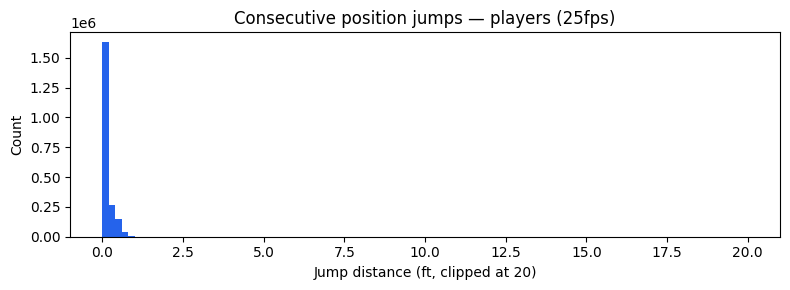

In [19]:
basic_info(moments, "moments")

print("\n  First 3 rows:")
display(moments.head(3))

# ─────────────────────────────────────────────────────────────
# CELL 7 — moments: ball vs players split
# ─────────────────────────────────────────────────────────────
ball      = moments[moments["player_id"] == -1]
players_m = moments[moments["player_id"] != -1]

print(f"  Ball rows   : {len(ball):,}")
print(f"  Player rows : {len(players_m):,}")
print(f"  Other rows  : {len(moments) - len(ball) - len(players_m):,}   ← should be 0")

# Each moment should have exactly 1 ball + 10 players = 11 rows
# Group by (game_id, quarter, game_clock) and count
moment_counts = moments.groupby(["game_id", "quarter", "game_clock"]).size()
print(f"\n  Rows per timestamp — expected 11 (1 ball + 10 players):")
print(moment_counts.value_counts().head(10).rename_axis("rows_per_ts").reset_index(name="count").to_string(index=False))


# ─────────────────────────────────────────────────────────────
# CELL 8 — moments: coordinate sanity
# ─────────────────────────────────────────────────────────────
print("  NBA court: x in [0, 94] ft,  y in [0, 50] ft\n")
for df, label in [(ball, "ball"), (players_m, "players")]:
    out_x = (df["x_loc"] < 0) | (df["x_loc"] > 94)
    out_y = (df["y_loc"] < 0) | (df["y_loc"] > 50)
    print(f"  [{label}]")
    print(f"    x_loc : {df['x_loc'].min():.2f}  –  {df['x_loc'].max():.2f}   |  out-of-bounds: {out_x.sum():,}")
    print(f"    y_loc : {df['y_loc'].min():.2f}  –  {df['y_loc'].max():.2f}   |  out-of-bounds: {out_y.sum():,}\n")

# ─────────────────────────────────────────────────────────────
# CELL 9 — moments: clock columns
# ─────────────────────────────────────────────────────────────
print("  game_clock  (expected 0 – 720 per quarter):")
print(f"    range  : {moments['game_clock'].min():.2f}  –  {moments['game_clock'].max():.2f}")
print(f"    < 0    : {(moments['game_clock'] < 0).sum():,}")
print(f"    > 720  : {(moments['game_clock'] > 720).sum():,}")

print("\n  shot_clock  (expected 0 – 24, nullable):")
print(f"    nulls  : {moments['shot_clock'].isnull().sum():,}  ({100*moments['shot_clock'].isnull().mean():.1f}%)")
sc = moments["shot_clock"].dropna()
print(f"    range  : {sc.min():.2f}  –  {sc.max():.2f}")
print(f"    < 0    : {(sc < 0).sum():,}")
print(f"    > 24   : {(sc > 24).sum():,}")

print(f"\n  quarter values: {sorted(moments['quarter'].dropna().unique().astype(int))}")
print(f"  (>4 means overtime)")


# ─────────────────────────────────────────────────────────────
# CELL 10 — moments: consecutive jump distances (teleport check)
# ─────────────────────────────────────────────────────────────
sample = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]   # game_clock counts DOWN
)
sample = sample.copy()
sample["x_next"] = sample.groupby(["game_id", "player_id"])["x_loc"].shift(-1)
sample["y_next"] = sample.groupby(["game_id", "player_id"])["y_loc"].shift(-1)
sample["jump_ft"] = np.sqrt(
    (sample["x_loc"] - sample["x_next"])**2 +
    (sample["y_loc"] - sample["y_next"])**2
)

jumps = sample["jump_ft"].dropna()
print(f"  Consecutive jump distances (feet between frames at 25fps):")
print(f"    mean   : {jumps.mean():.3f}")
print(f"    median : {jumps.median():.3f}")
print(f"    95th % : {jumps.quantile(0.95):.3f}")
print(f"    max    : {jumps.max():.3f}")
print(f"    > 10ft : {(jumps > 10).sum():,}  ({100*(jumps > 10).mean():.2f}%)  ← likely substitutions/gaps")
print(f"    > 50ft : {(jumps > 50).sum():,}  ← genuine data errors")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(jumps.clip(upper=20), bins=100, color="#2563eb", edgecolor="none")
ax.set_xlabel("Jump distance (ft, clipped at 20)")
ax.set_ylabel("Count")
ax.set_title("Consecutive position jumps — players (25fps)")
plt.tight_layout()
plt.show()



In [20]:
moment_counts = moments.groupby(["game_id", "quarter", "game_clock"]).size()
print(f"\n  Rows per timestamp — expected 11 (1 ball + 10 players):")
print(moment_counts.value_counts().head(10).rename_axis("rows_per_ts").reset_index(name="count").to_string(index=False))
moments_grouped = moments.groupby(["game_id", "quarter", "game_clock"])
moments.groupby(["game_id", "quarter", "game_clock"]).size()



  Rows per timestamp — expected 11 (1 ball + 10 players):
 rows_per_ts  count
          22  26225
          11  15655
          33  14428
          44   8734
          55   3034
          66   1719
          77    859
          88    150
          10     64
          20     41


game_id   quarter  game_clock
21500548  1        0.00          44
                   0.04          44
                   0.08          44
                   0.12          44
                   0.16          44
                                 ..
          4        718.27        11
                   718.31        11
                   718.35        11
                   718.39        11
                   718.43        11
Length: 71014, dtype: int64

In [21]:
moments.sort_values(["game_id", "quarter", "game_clock", "player_id"]).head(30)

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
533405,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,113
534318,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,114
535231,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,117
536144,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,119
533412,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,113
534325,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,114
535238,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,117
536151,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,119
533411,1610612744,2738,55.51012,24.73840,0.0000,0.0,NaN,1,21500548,113
534324,1610612744,2738,55.51012,24.73840,0.0000,0.0,NaN,1,21500548,114


  moments  —  781,044 rows  x  10 cols


,dtype,non_null,null,null_%,nunique,sample
team_id,int64,781044,0,0.0,3,-1.000000e+00
player_id,int64,781044,0,0.0,24,-1.000000e+00
x_loc,float64,781044,0,0.0,744457,4.722664e+01
y_loc,float64,781044,0,0.0,714037,3.085514e+01
radius,float64,781044,0,0.0,67407,4.139880e+00
game_clock,float64,781044,0,0.0,47449,7.142800e+02
shot_clock,float64,747501,33543,4.3,2313,1.737000e+01
quarter,int64,781044,0,0.0,4,1.000000e+00
game_id,int64,781044,0,0.0,1,2.150055e+07
event_id,int64,781044,0,0.0,261,1.000000e+00



  First 3 rows:


,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1


  Ball rows   : 70,881
  Player rows : 710,163
  Other rows  : 0   ← should be 0

  Rows per timestamp — expected 11 (1 ball + 10 players):
 rows_per_ts  count
          11  70867
          10    133
          13      9
          12      5
  NBA court: x in [0, 94] ft,  y in [0, 50] ft

  [ball]
    x_loc : -5.40  –  99.84   |  out-of-bounds: 1,113
    y_loc : -2.82  –  53.11   |  out-of-bounds: 155

  [players]
    x_loc : -7.44  –  98.07   |  out-of-bounds: 3,331
    y_loc : -3.09  –  51.98   |  out-of-bounds: 795

  game_clock  (expected 0 – 720 per quarter):
    range  : 0.00  –  718.43
    < 0    : 0
    > 720  : 0

  shot_clock  (expected 0 – 24, nullable):
    nulls  : 33,543  (4.3%)
    range  : 0.01  –  24.00
    < 0    : 0
    > 24   : 0

  quarter values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  (>4 means overtime)
  Consecutive jump distances (feet between frames at 25fps):
    mean   : 0.358
    median : 0.221
    95th % : 0.611
    max    : 89.369
    > 10ft

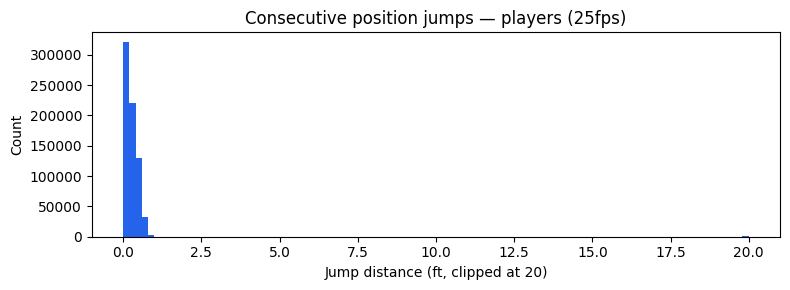

In [22]:
dropped_dups_moments = moments.drop_duplicates(
    subset=["game_id", "player_id", "quarter", "game_clock"]
)

basic_info(dropped_dups_moments, "moments")

print("\n  First 3 rows:")
display(dropped_dups_moments.head(3))

# ─────────────────────────────────────────────────────────────
# CELL 7 — moments: ball vs players split
# ─────────────────────────────────────────────────────────────
ball      = dropped_dups_moments[dropped_dups_moments["player_id"] == -1]
players_m = dropped_dups_moments[dropped_dups_moments["player_id"] != -1]

print(f"  Ball rows   : {len(ball):,}")
print(f"  Player rows : {len(players_m):,}")
print(f"  Other rows  : {len(dropped_dups_moments) - len(ball) - len(players_m):,}   ← should be 0")

# Each moment should have exactly 1 ball + 10 players = 11 rows
# Group by (game_id, quarter, game_clock) and count
moment_counts = dropped_dups_moments.groupby(["game_id", "quarter", "game_clock"]).size()
print(f"\n  Rows per timestamp — expected 11 (1 ball + 10 players):")
print(moment_counts.value_counts().head(10).rename_axis("rows_per_ts").reset_index(name="count").to_string(index=False))


# ─────────────────────────────────────────────────────────────
# CELL 8 — moments: coordinate sanity
# ─────────────────────────────────────────────────────────────
print("  NBA court: x in [0, 94] ft,  y in [0, 50] ft\n")
for df, label in [(ball, "ball"), (players_m, "players")]:
    out_x = (df["x_loc"] < 0) | (df["x_loc"] > 94)
    out_y = (df["y_loc"] < 0) | (df["y_loc"] > 50)
    print(f"  [{label}]")
    print(f"    x_loc : {df['x_loc'].min():.2f}  –  {df['x_loc'].max():.2f}   |  out-of-bounds: {out_x.sum():,}")
    print(f"    y_loc : {df['y_loc'].min():.2f}  –  {df['y_loc'].max():.2f}   |  out-of-bounds: {out_y.sum():,}\n")

# ─────────────────────────────────────────────────────────────
# CELL 9 — moments: clock columns
# ─────────────────────────────────────────────────────────────
print("  game_clock  (expected 0 – 720 per quarter):")
print(f"    range  : {dropped_dups_moments['game_clock'].min():.2f}  –  {dropped_dups_moments['game_clock'].max():.2f}")
print(f"    < 0    : {(dropped_dups_moments['game_clock'] < 0).sum():,}")
print(f"    > 720  : {(dropped_dups_moments['game_clock'] > 720).sum():,}")

print("\n  shot_clock  (expected 0 – 24, nullable):")
print(f"    nulls  : {dropped_dups_moments['shot_clock'].isnull().sum():,}  ({100*dropped_dups_moments['shot_clock'].isnull().mean():.1f}%)")
sc = dropped_dups_moments["shot_clock"].dropna()
print(f"    range  : {sc.min():.2f}  –  {sc.max():.2f}")
print(f"    < 0    : {(sc < 0).sum():,}")
print(f"    > 24   : {(sc > 24).sum():,}")

print(f"\n  quarter values: {sorted(dropped_dups_moments['quarter'].dropna().unique().astype(int))}")
print(f"  (>4 means overtime)")


# ─────────────────────────────────────────────────────────────
# CELL 10 — moments: consecutive jump distances (teleport check)
# ─────────────────────────────────────────────────────────────
sample = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]   # game_clock counts DOWN
)
sample = sample.copy()
sample["x_next"] = sample.groupby(["game_id", "player_id"])["x_loc"].shift(-1)
sample["y_next"] = sample.groupby(["game_id", "player_id"])["y_loc"].shift(-1)
sample["jump_ft"] = np.sqrt(
    (sample["x_loc"] - sample["x_next"])**2 +
    (sample["y_loc"] - sample["y_next"])**2
)

jumps = sample["jump_ft"].dropna()
print(f"  Consecutive jump distances (feet between frames at 25fps):")
print(f"    mean   : {jumps.mean():.3f}")
print(f"    median : {jumps.median():.3f}")
print(f"    95th % : {jumps.quantile(0.95):.3f}")
print(f"    max    : {jumps.max():.3f}")
print(f"    > 10ft : {(jumps > 10).sum():,}  ({100*(jumps > 10).mean():.2f}%)  ← likely substitutions/gaps")
print(f"    > 50ft : {(jumps > 50).sum():,}  ← genuine data errors")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(jumps.clip(upper=20), bins=100, color="#2563eb", edgecolor="none")
ax.set_xlabel("Jump distance (ft, clipped at 20)")
ax.set_ylabel("Count")
ax.set_title("Consecutive position jumps — players (25fps)")
plt.tight_layout()
plt.show()



In [23]:
moments.sort_values(["game_id", "quarter", "game_clock", "player_id"]).head(30)

# Drop duplicates - keep one row per player per timestamp
moments_deduped = moments.drop_duplicates(
    subset=["game_id", "player_id", "quarter", "game_clock"]
).copy()

print(f"Before dedup: {len(moments):,}")
print(f"After dedup:  {len(moments_deduped):,}")

# Filter out ball
players_m = moments_deduped[moments_deduped["player_id"] != -1].copy()

# Sort chronologically — game_clock counts DOWN so descending = forward in time
players_m = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]
)

players_m.groupby(["game_id", "player_id"])['x_loc'].head(3)

Before dedup: 2,303,443
After dedup:  781,044


445137     91.07233
445148     91.06242
445159     91.04258
314907      3.76209
314918      3.78855
             ...   
2084134    22.86218
2084144    23.33792
2084126     4.60263
2084136     4.65700
2084146     4.71947
Name: x_loc, Length: 69, dtype: float64

In [24]:
# Drop duplicates - keep one row per player per timestamp
moments_deduped = moments.drop_duplicates(
    subset=["game_id", "player_id", "quarter", "game_clock"]
).copy()

print(f"Before dedup: {len(moments):,}")
print(f"After dedup:  {len(moments_deduped):,}")

# Filter out ball
players_m = moments_deduped[moments_deduped["player_id"] != -1].copy()

# Sort chronologically — game_clock counts DOWN so descending = forward in time
players_m = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]
)

# Get next position for each player within the same game
players_m["x_next"] = players_m.groupby(["game_id", "player_id"])["x_loc"].shift(-1)
players_m["y_next"] = players_m.groupby(["game_id", "player_id"])["y_loc"].shift(-1)

# Euclidean distance in feet, converted to meters
players_m["dist_m"] = np.sqrt(
    (players_m["x_loc"] - players_m["x_next"])**2 +
    (players_m["y_loc"] - players_m["y_next"])**2
) * 0.3048

# Total distance per player (across all games in the dataset)
total_distance = (
    players_m
    .groupby("player_id")["dist_m"]
    .sum()
    .reset_index()
    .rename(columns={"dist_m": "total_distance_m"})
    .sort_values("total_distance_m", ascending=False)
)

print(f"\nTotal distance per player:")
display(total_distance)


Before dedup: 2,303,443
After dedup:  781,044

Total distance per player:


,player_id,total_distance_m
17,203468,5865.508700
10,203081,5561.912182
15,203110,5504.615863
16,203459,5313.299068
9,202691,5290.645024
3,201575,4904.834452
5,201939,4338.070733
13,203090,3971.855078
11,203084,3810.629867
7,202329,3362.648427


In [25]:
# Sum seconds played across all games for each player (season total)
total_minutes = (
    minutes
    .groupby("PLAYER_ID")["SEC"]
    .sum()
    .reset_index()
    .rename(columns={"PLAYER_ID": "player_id", "SEC": "total_seconds_played"})
)

# Join total distance with total seconds played
result = total_distance.merge(total_minutes, on="player_id", how="left")

# Apply formula: TotalDistance * 12 / minutes_played
result["minutes_played"]         = result["total_seconds_played"] / 60
result["distance_per_quarter_m"] = (
    result["total_distance_m"] * 12 / result["minutes_played"]
).round(0).astype("Int64")

# Flag players with no minutes data
missing = result["total_seconds_played"].isna().sum()
print(f"Players with no entry in minutes_played: {missing} — will have NaN distance_per_quarter")

# Final output
result_final = result[["player_id", "distance_per_quarter_m"]].sort_values(
    "distance_per_quarter_m", ascending=False
)
print("\nDistance per quarter per player (meters):")
display(result_final)

Players with no entry in minutes_played: 0 — will have NaN distance_per_quarter

Distance per quarter per player (meters):


,player_id,distance_per_quarter_m
14,201945,945
1,203081,867
7,203090,866
21,1626192,855
3,203459,671
0,203468,662
15,203086,580
17,203943,575
9,202329,549
18,202334,534


In [26]:
moments_deduped

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1
3,1610612757,203486,76.35817,32.72804,0.00000,714.28,17.37,1,21500548,1
4,1610612757,203468,83.68322,6.07262,0.00000,714.28,17.37,1,21500548,1
...,...,...,...,...,...,...,...,...,...,...
2303438,1610612744,201575,43.66537,40.42003,0.00000,0.04,NaN,4,21500548,539
2303439,1610612744,201578,44.70719,15.92969,0.00000,0.04,NaN,4,21500548,539
2303440,1610612744,203105,73.66245,0.95057,0.00000,0.04,NaN,4,21500548,539
2303441,1610612744,203546,43.85332,29.92151,0.00000,0.04,NaN,4,21500548,539


3-point shot events found: 65


,EVENTNUM,PERIOD,PCTIMESTRING,PLAYER1_ID,PLAYER1_NAME,EVENTMSGTYPE,HOMEDESCRIPTION,VISITORDESCRIPTION
9,9,1,11:00,201939,Stephen Curry,1,NaN,Curry 3PT Jump Shot (3 PTS) (Green 1 AST)
33,37,1,8:05,201939,Stephen Curry,2,NaN,MISS Curry 3PT Jump Shot
39,43,1,7:45,201575,Brandon Rush,1,NaN,Rush 3PT Jump Shot (3 PTS) (Thompson 1 AST)
41,46,1,7:28,202329,Al-Farouq Aminu,2,MISS Aminu 24' 3PT Jump Shot,NaN
44,49,1,6:56,201939,Stephen Curry,2,NaN,MISS Curry 25' 3PT Jump Shot
48,53,1,6:30,201575,Brandon Rush,1,NaN,Rush 3PT Jump Shot (6 PTS) (Thompson 2 AST)
52,58,1,5:42,203468,CJ McCollum,2,MISS McCollum 26' 3PT Jump Shot,NaN
66,72,1,4:28,202691,Klay Thompson,1,NaN,Thompson 25' 3PT Jump Shot (5 PTS) (Bogut 1 AST)
71,77,1,3:51,203081,Damian Lillard,1,Lillard 25' 3PT Jump Shot (7 PTS),NaN
72,78,1,3:39,202691,Klay Thompson,1,NaN,Thompson 25' 3PT Jump Shot (8 PTS) (Curry 3 AST)



Matched shot locations: 20


,player_id,player_name,x_loc,y_loc,made,period,game_clock
0,201939,Stephen Curry,24.841118,15.244727,True,1,660
1,201939,Stephen Curry,21.782581,14.451437,False,1,485
2,201575,Brandon Rush,25.249879,0.352712,True,1,465
3,202329,Al-Farouq Aminu,9.802383,5.782211,False,1,448
4,201939,Stephen Curry,18.267999,2.601480,False,1,416
5,201575,Brandon Rush,22.017603,1.596914,True,1,390
6,203468,CJ McCollum,9.487933,13.045272,False,1,342
7,202691,Klay Thompson,12.325012,11.828785,True,1,268
8,203081,Damian Lillard,11.344107,11.607842,True,1,231
9,202691,Klay Thompson,15.389821,1.819839,True,1,219


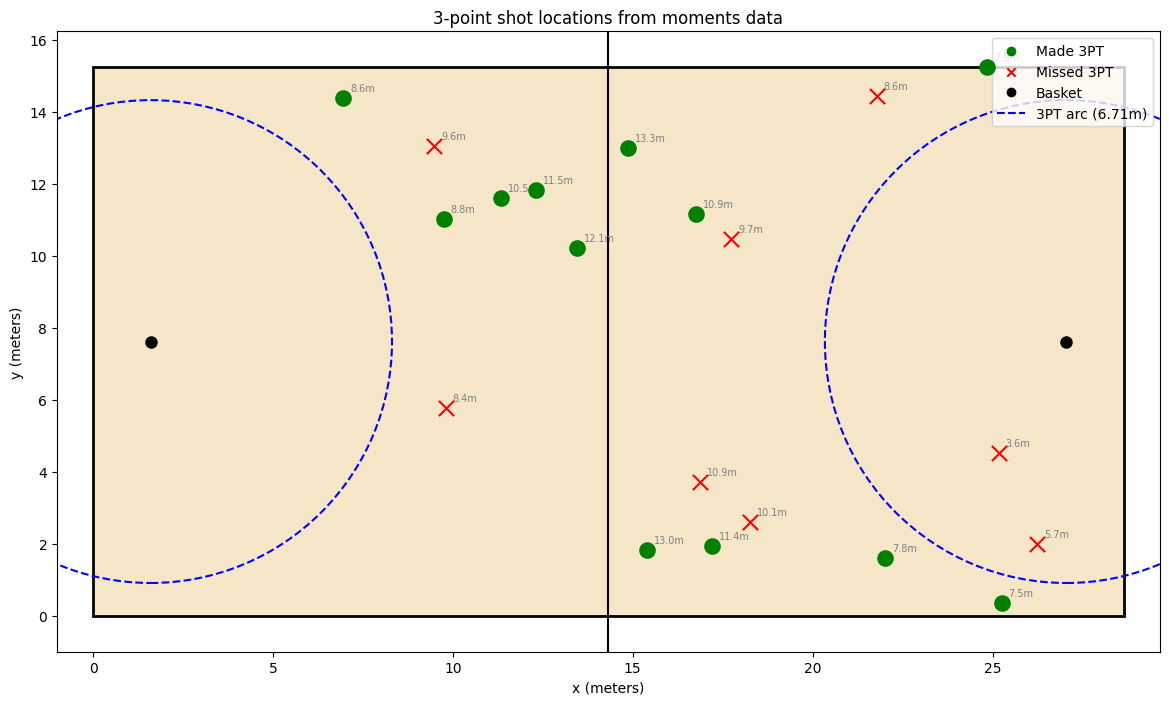


Distance to nearest basket for each shot:
  Stephen Curry         dist=7.94m  ✓
  Stephen Curry         dist=8.63m  ✓
  Brandon Rush          dist=7.49m  ✓
  Al-Farouq Aminu       dist=8.41m  ✓
  Stephen Curry         dist=10.12m  ✓
  Brandon Rush          dist=7.85m  ✓
  CJ McCollum           dist=9.57m  ✓
  Klay Thompson         dist=11.52m  ✓
  Damian Lillard        dist=10.53m  ✓
  Klay Thompson         dist=13.02m  ✓
  Allen Crabbe          dist=3.61m  ✗ INSIDE ARC — check sync!
  Klay Thompson         dist=13.31m  ✓
  Klay Thompson         dist=12.12m  ✓
  Klay Thompson         dist=8.84m  ✓
  Maurice Harkless      dist=8.62m  ✓
  Ian Clark             dist=11.36m  ✓
  Allen Crabbe          dist=10.91m  ✓
  Harrison Barnes       dist=5.69m  ✗ INSIDE ARC — check sync!
  Ian Clark             dist=10.90m  ✓
  Stephen Curry         dist=9.74m  ✓


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Get 3-point shot events from events table
# EVENTMSGTYPE 1 = made, 2 = missed
# 3-pointers are identified by "3PT" in the description
three_pt_events = events[
    events["EVENTMSGTYPE"].isin([1, 2]) &
    (
        events["HOMEDESCRIPTION"].str.contains("3PT", na=False) |
        events["VISITORDESCRIPTION"].str.contains("3PT", na=False)
    )
].copy()

print(f"3-point shot events found: {len(three_pt_events)}")
display(three_pt_events[["EVENTNUM", "PERIOD", "PCTIMESTRING", "PLAYER1_ID", 
                           "PLAYER1_NAME", "EVENTMSGTYPE", "HOMEDESCRIPTION", 
                           "VISITORDESCRIPTION"]].head(10))

# For each 3pt event, find the player's position in moments at that timestamp
# PCTIMESTRING is "MM:SS" left on clock → convert to game_clock seconds
def pctimestring_to_seconds(t):
    try:
        m, s = t.strip().split(":")
        return int(m) * 60 + int(s)
    except:
        return None

three_pt_events["game_clock_approx"] = three_pt_events["PCTIMESTRING"].apply(pctimestring_to_seconds)
three_pt_events["PERIOD"] = three_pt_events["PERIOD"].astype(int)

# Merge with moments on period + game_clock (approximate — within 1 second)
# since pbp and tracking timestamps may not be perfectly synced
shot_locations = []

for _, event in three_pt_events.head(20).iterrows():
    player_id  = event["PLAYER1_ID"]
    period     = event["PERIOD"]
    game_clock = event["game_clock_approx"]
    made       = event["EVENTMSGTYPE"] == 1

    if game_clock is None:
        continue

    # Find the closest moment for this player at this time
    candidate = moments_copy[
        (moments_copy["player_id"] == player_id) &
        (moments_copy["quarter"]   == period) &
        (moments_copy["game_clock"].between(game_clock - 1, game_clock + 1))
    ].copy()

    if len(candidate) == 0:
        continue

    # Pick the row closest to the exact game_clock
    candidate["clock_diff"] = (candidate["game_clock"] - game_clock).abs()
    closest = candidate.sort_values("clock_diff").iloc[0]

    shot_locations.append({
        "player_id"  : player_id,
        "player_name": event["PLAYER1_NAME"],
        "x_loc"      : closest["x_loc"],   # already in meters after preprocessing
        "y_loc"      : closest["y_loc"],
        "made"       : made,
        "period"     : period,
        "game_clock" : game_clock,
    })

shot_df = pd.DataFrame(shot_locations)
print(f"\nMatched shot locations: {len(shot_df)}")
display(shot_df)

# ── Plot ──────────────────────────────────────────────────────────────────────
FEET_TO_M        = 0.3048
COURT_W          = 94  * FEET_TO_M   # 28.65m
COURT_H          = 50  * FEET_TO_M   # 15.24m
LEFT_BASKET_X    = 5.25  * FEET_TO_M
RIGHT_BASKET_X   = 88.75 * FEET_TO_M
BASKET_Y         = 25   * FEET_TO_M
THREE_PT_RADIUS  = 6.71              # meters (from assignment)
HALF_COURT       = COURT_W / 2

fig, ax = plt.subplots(figsize=(12, 7))

# Court outline
court = patches.Rectangle((0, 0), COURT_W, COURT_H,
                            linewidth=2, edgecolor="black", facecolor="#f5e6c8")
ax.add_patch(court)

# Half court line
ax.axvline(HALF_COURT, color="black", lw=1.5)

# Baskets
ax.plot(LEFT_BASKET_X,  BASKET_Y, "ko", markersize=8, zorder=5)
ax.plot(RIGHT_BASKET_X, BASKET_Y, "ko", markersize=8, zorder=5)

# 3-point arcs
left_arc  = patches.Circle((LEFT_BASKET_X,  BASKET_Y), THREE_PT_RADIUS,
                             fill=False, edgecolor="blue", lw=1.5, linestyle="--")
right_arc = patches.Circle((RIGHT_BASKET_X, BASKET_Y), THREE_PT_RADIUS,
                             fill=False, edgecolor="blue", lw=1.5, linestyle="--")
ax.add_patch(left_arc)
ax.add_patch(right_arc)

# Plot shot locations
for _, shot in shot_df.iterrows():
    x, y = shot["x_loc"], shot["y_loc"]

    # Compute distance to nearest basket
    dist_left  = np.sqrt((x - LEFT_BASKET_X)**2  + (y - BASKET_Y)**2)
    dist_right = np.sqrt((x - RIGHT_BASKET_X)**2 + (y - BASKET_Y)**2)
    dist       = min(dist_left, dist_right)

    color  = "green" if shot["made"] else "red"
    marker = "o"     if shot["made"] else "x"

    ax.scatter(x, y, c=color, marker=marker, s=120, zorder=6)
    ax.annotate(f"{dist:.1f}m", (x, y), textcoords="offset points",
                xytext=(5, 5), fontsize=7, color="gray")

# Legend
ax.scatter([], [], c="green", marker="o", label="Made 3PT")
ax.scatter([], [], c="red",   marker="x", label="Missed 3PT")
ax.plot   ([], [], "ko",                  label="Basket")
ax.plot   ([], [], "b--",                 label=f"3PT arc ({THREE_PT_RADIUS}m)")

ax.set_xlim(-1, COURT_W + 1)
ax.set_ylim(-1, COURT_H + 1)
ax.set_xlabel("x (meters)")
ax.set_ylabel("y (meters)")
ax.set_title("3-point shot locations from moments data")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Sanity check — all shots should be OUTSIDE the 3pt arc
print("\nDistance to nearest basket for each shot:")
for _, shot in shot_df.iterrows():
    x, y       = shot["x_loc"], shot["y_loc"]
    dist_left  = np.sqrt((x - LEFT_BASKET_X)**2  + (y - BASKET_Y)**2)
    dist_right = np.sqrt((x - RIGHT_BASKET_X)**2 + (y - BASKET_Y)**2)
    dist       = min(dist_left, dist_right)
    flag       = "✓" if dist > THREE_PT_RADIUS else "✗ INSIDE ARC — check sync!"
    print(f"  {shot['player_name']:20s}  dist={dist:.2f}m  {flag}")

            x_loc     y_loc   radius  game_clock  quarter
420149    3.79661  26.53122  0.03077      175.42        1
418510    3.79661  26.53122  0.03077      175.42        1
423383    3.79661  26.53122  0.03077      175.42        1
2075637  56.42225  25.58312  0.04236      298.23        4
2077298  56.42225  25.58312  0.04236      298.23        4
1298505  31.93638   9.67501  0.06811      590.12        3
1290805  31.93638   9.67501  0.06811      590.12        3
750576   82.80037  25.21881  0.09778      432.16        2
756901   82.80037  25.21881  0.09778      432.16        2
756912   82.59902  25.34136  0.09963      432.12        2
750587   82.59902  25.34136  0.09963      432.12        2
2300594  51.10342  27.13678  0.10101       10.42        4
2298944  51.10342  27.13678  0.10101       10.42        4
436220   37.24290  23.44747  0.10568      151.65        1
1057182   6.55870  22.49024  0.11776      113.63        2
1062770   6.55870  22.49024  0.11776      113.63        2
441852   90.97

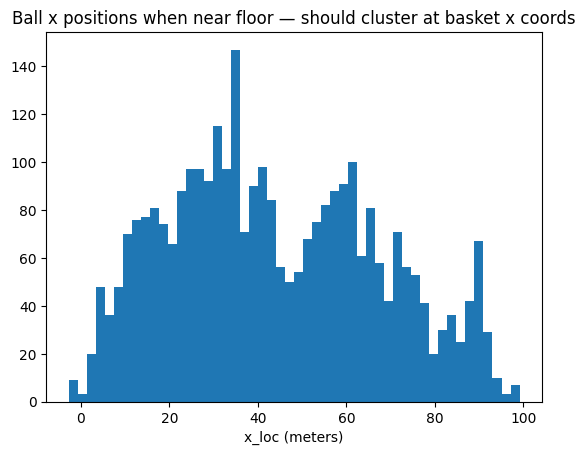

In [28]:
# Ball moments where radius is very low (ball near floor, just passed through hoop)
ball = moments[moments["player_id"] == -1].copy()

# Convert back to feet for inspection if needed
low_ball = ball[ball["radius"] < 0.5].sort_values("radius")
print(low_ball[["x_loc", "y_loc", "radius", "game_clock", "quarter"]].head(20))

# The x_loc values should cluster around your basket x coordinates
import matplotlib.pyplot as plt
plt.hist(low_ball["x_loc"], bins=50)
plt.xlabel("x_loc (meters)")
plt.title("Ball x positions when near floor — should cluster at basket x coords")
plt.show()

In [ ]:
moments

In [32]:
ball = moments[moments["player_id"] == -1].copy()

FEET_TO_METERS = 0.3048
ball["radius_m"] = ball["radius"] * FEET_TO_METERS

# Get event numbers that are shot events (EVENTMSGTYPE 1 or 2) from events table
shot_event_nums = events[events["EVENTMSGTYPE"].isin([1, 2])]["EVENTNUM"].unique()

# Filter ball moments where event_id matches one of those event numbers
ball_shots = ball[ball["event_id"].isin(shot_event_nums)]

print(f"Total ball rows:                             {len(ball):,}")
print(f"Ball rows in shot events:                    {len(ball_shots):,}")
print(f"Ball rows with radius >= 2m in shot events:  {len(ball_shots[ball_shots['radius_m'] >= 2.0]):,}")
print(f"Percentage above 2m:                         {100 * len(ball_shots[ball_shots['radius_m'] >= 2.0]) / len(ball_shots):.1f}%")

print("\nBall height distribution in shot events (meters):")
print(ball_shots["radius_m"].describe())

Total ball rows:                             208,993
Ball rows in shot events:                    87,523
Ball rows with radius >= 2m in shot events:  17,682
Percentage above 2m:                         20.2%

Ball height distribution in shot events (meters):
count    87523.000000
mean         1.463851
std          0.978513
min          0.009379
25%          0.866726
50%          1.197651
75%          1.749813
max          5.273406
Name: radius_m, dtype: float64


In [ ]:
# Get event numbers for made shots only (EVENTMSGTYPE == 1)
made_shot_event_nums = events[events["EVENTMSGTYPE"] == 1]["EVENTNUM"].unique()
print(f"Total made shot events:  {len(made_shot_event_nums):,}")

# Filter ball moments to made shot events
ball_made = ball[ball["event_id"].isin(mabde_shot_event_nums)]

# For each event, check if there is at least one moment with ball >= 2m
events_above_2m = ball_made[ball_made["radius_m"] >= 1.6]["event_id"].unique()
events_not_above_2m = set(made_shot_event_nums) - set(ball_made["event_id"].unique())  # events with no ball moments at all
events_with_ball_moments = ball_made["event_id"].unique()

print(f"Made shot events with ball moments in tracking data: {len(events_with_ball_moments):,}")
print(f"Made shot events with NO ball moments in tracking:   {len(events_not_above_2m):,}")
print(f"Made shot events with at least one moment >= 2m:     {len(events_above_2m):,}")
print(f"Made shot events with NO moment >= 2m:               {len(events_with_ball_moments) - len(events_above_2m):,}")
print(f"\nCoverage: {100 * len(events_above_2m) / len(made_shot_event_nums):.1f}% of made shots have a ball moment >= 2m")

Total made shot events:  84
Made shot events with ball moments in tracking data: 83
Made shot events with NO ball moments in tracking:   1
Made shot events with at least one moment >= 2m:     82
Made shot events with NO moment >= 2m:               1

Coverage: 97.6% of made shots have a ball moment >= 2m


Gap distribution between consecutive frames:
  min    : 0.0000
  mean   : 0.0144
  median : 0.0000
  max    : 449.4200

Percentile breakdown:
  90th  : 0.0400
  95th  : 0.0400
  99th  : 0.0400
  99.9th  : 0.0500

Gap counts by range:
  <= 0.04  : 1,777,788
  <= 0.05  : 2,086,545
  <= 0.10  : 2,094,176
  <= 0.50  : 2,094,287
  > 0.50   : 90
  > 1.00   : 58


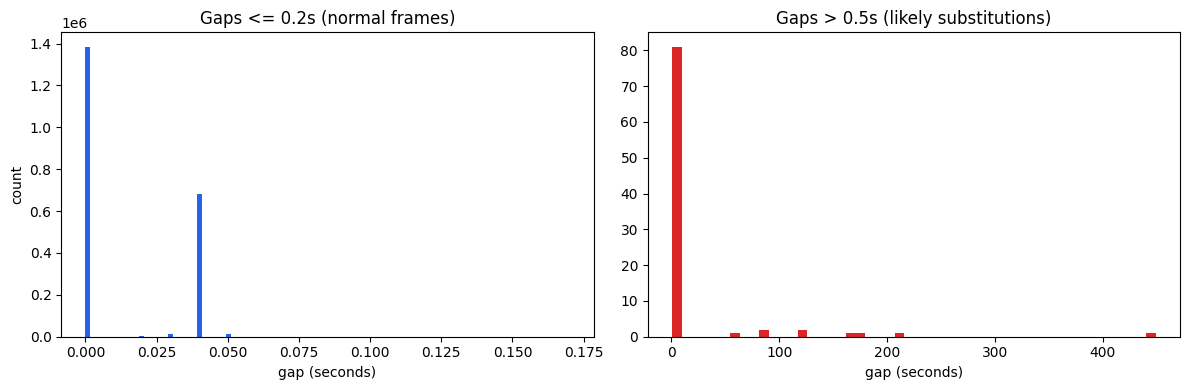

In [44]:
players = moments[moments["player_id"] != -1].copy()

players_sorted = players.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]
)

players_sorted["clock_next"] = players_sorted.groupby(
    ["game_id", "player_id", "quarter"]
)["game_clock"].shift(-1)

players_sorted["clock_gap"] = players_sorted["game_clock"] - players_sorted["clock_next"]

gaps = players_sorted["clock_gap"].dropna()

print("Gap distribution between consecutive frames:")
print(f"  min    : {gaps.min():.4f}")
print(f"  mean   : {gaps.mean():.4f}")
print(f"  median : {gaps.median():.4f}")
print(f"  max    : {gaps.max():.4f}")
print(f"\nPercentile breakdown:")
for p in [90, 95, 99, 99.9]:
    print(f"  {p}th  : {gaps.quantile(p/100):.4f}")

print(f"\nGap counts by range:")
print(f"  <= 0.04  : {(gaps <= 0.04).sum():,}")
print(f"  <= 0.05  : {(gaps <= 0.05).sum():,}")
print(f"  <= 0.10  : {(gaps <= 0.10).sum():,}")
print(f"  <= 0.50  : {(gaps <= 0.50).sum():,}")
print(f"  > 0.50   : {(gaps > 0.50).sum():,}")
print(f"  > 1.00   : {(gaps > 1.00).sum():,}")

# Plot the distribution of small gaps to find the natural cutoff
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: zoom in on small gaps to see the normal frame rate
ax1.hist(gaps[gaps <= 0.2], bins=100, color="#2563eb", edgecolor="none")
ax1.set_xlabel("gap (seconds)")
ax1.set_ylabel("count")
ax1.set_title("Gaps <= 0.2s (normal frames)")

# Right: large gaps only — these are substitutions
ax2.hist(gaps[gaps > 0.5], bins=50, color="#dc2626", edgecolor="none")
ax2.set_xlabel("gap (seconds)")
ax2.set_title("Gaps > 0.5s (likely substitutions)")

plt.tight_layout()
plt.show()

In [45]:
possession = moments[moments["player_id"] != -1].copy()

# simulate possession moments — approximate by just checking gap sizes
possession_sorted = possession.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]
)

possession_sorted["clock_next"] = possession_sorted.groupby(
    ["game_id", "player_id", "quarter"]
)["game_clock"].shift(-1)

possession_sorted["gap"] = possession_sorted["game_clock"] - possession_sorted["clock_next"]

gaps = possession_sorted["gap"].dropna()
print(f"Gaps <= 0.5s  (kept)    : {(gaps <= 0.5).sum():,}")
print(f"Gaps >  0.5s  (filtered): {(gaps > 0.5).sum():,}")
print(f"Filtered as % of total  : {100*(gaps > 0.5).mean():.2f}%")

Gaps <= 0.5s  (kept)    : 2,094,287
Gaps >  0.5s  (filtered): 90
Filtered as % of total  : 0.00%
